In [136]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [137]:
df = pd.read_csv('Pakistan Largest Ecommerce Dataset.csv')

/tmp/ipykernel_1021/3463096870.py:1: DtypeWarning:

Columns (1,2,3,7,8,9,11,12,13,14,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.



In [138]:
df.head()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.00,complete,7/1/2016,kreations_YI 06-L,1950.00,1.00,1950.00,100147443,Women's Fashion,\N,...,7.00,2016-7,7-2016,FY17,1.00,NaN,NaN,NaN,NaN,NaN
1,211133.00,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.00,1.00,240.00,100147444,Beauty & Grooming,\N,...,7.00,2016-7,7-2016,FY17,2.00,NaN,NaN,NaN,NaN,NaN
2,211134.00,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.00,1.00,2450.00,100147445,Women's Fashion,\N,...,7.00,2016-7,7-2016,FY17,3.00,NaN,NaN,NaN,NaN,NaN
3,211135.00,complete,7/1/2016,kcc_krone deal,360.00,1.00,60.00,100147446,Beauty & Grooming,R-FSD-52352,...,7.00,2016-7,7-2016,FY17,4.00,NaN,NaN,NaN,NaN,NaN
4,211136.00,order_refunded,7/1/2016,BK7010400AG,555.00,2.00,1110.00,100147447,Soghaat,\N,...,7.00,2016-7,7-2016,FY17,5.00,NaN,NaN,NaN,NaN,NaN


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  object 
 9   sales_commission_code  447346 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV                    584524 non-

In [140]:
df = df.drop(['Unnamed: 21', 'Unnamed: 22','Unnamed: 23','Unnamed: 24','Unnamed: 25'], axis=1)

In [141]:
NULL_SENTINELS = {"\\N": np.nan, "#REF!": np.nan}
df = df.replace(NULL_SENTINELS)

In [142]:
df.shape

(1048575, 21)

In [143]:
df.describe()

,item_id,price,qty_ordered,grand_total,discount_amount,Year,Month,Customer ID
count,584524.00,584524.00,584524.00,584524.00,584524.00,584524.00,584524.00,584513.00
mean,565667.07,6348.75,1.30,8530.62,499.49,2017.04,7.17,45790.51
std,200121.17,14949.27,4.00,61320.81,1506.94,0.71,3.49,34414.96
min,211131.00,0.00,1.00,-1594.00,-599.50,2016.00,1.00,1.00
25%,395000.75,360.00,1.00,945.00,0.00,2017.00,4.00,13516.00
50%,568424.50,899.00,1.00,1960.40,0.00,2017.00,7.00,42856.00
75%,739106.25,4070.00,1.00,6999.00,160.50,2018.00,11.00,73536.00
max,905208.00,1012625.90,1000.00,17888000.00,90300.00,2018.00,12.00,115326.00


In [144]:
df.describe(include='object')

,status,created_at,sku,increment_id,category_name_1,sales_commission_code,payment_method,Working Date,BI Status,MV,Customer Since,M-Y,FY
count,584505,584524,584504,584524,576510,108345,584524,584524,584523,584524,584513,584524,584524
unique,15,789,84889,408785,15,7224,18,789,3,9720,26,26,3
top,complete,11/25/2016,MATSAM59DB75ADB2F80,100266667,Mobiles & Tablets,40968,cod,11/25/2016,Net,999,2016-11,11-2017,FY18
freq,233685,15169,3775,72,115710,2710,271960,15169,234178,9516,82714,83928,306883


In [145]:
df.isnull().sum()

,0
item_id,464051
status,464070
created_at,464051
sku,464071
price,464051
qty_ordered,464051
grand_total,464051
increment_id,464051
category_name_1,472065
sales_commission_code,940230


In [146]:
df.isnull().sum().sort_values(ascending=False)

,0
sales_commission_code,940230
category_name_1,472065
sku,464071
status,464070
Customer Since,464062
Customer ID,464062
BI Status,464052
item_id,464051
created_at,464051
price,464051


In [147]:
df.duplicated().sum()

np.int64(464050)

In [148]:
df.drop_duplicates(inplace=True)

In [149]:
df.isnull().sum().sort_values(ascending=False)

,0
sales_commission_code,476180
category_name_1,8015
sku,21
status,20
Customer Since,12
Customer ID,12
BI Status,2
item_id,1
created_at,1
price,1


In [150]:
df[df['price'].isnull()]

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
584524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [151]:
df.dropna(subset=['price'], inplace=True)

In [152]:
df.isnull().sum().sort_values(ascending=False)

,0
sales_commission_code,476179
category_name_1,8014
sku,20
status,19
Customer Since,11
Customer ID,11
BI Status,1
item_id,0
created_at,0
price,0


In [153]:
df.shape

(584524, 21)

In [154]:
df['sales_commission_code'].fillna('No Commission', inplace=True)

/tmp/ipykernel_1021/4021038605.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [155]:
sku_to_cat = df.dropna(subset=['category_name_1']).set_index('sku')['category_name_1'].to_dict()
df['category_name_1'] = df['category_name_1'].fillna(df['sku'].map(sku_to_cat))

In [156]:
df.isnull().sum().sort_values(ascending=False)

,0
category_name_1,5863
sku,20
status,19
Customer ID,11
Customer Since,11
BI Status,1
price,0
item_id,0
created_at,0
sales_commission_code,0


In [157]:
df.shape

(584524, 21)

In [158]:
df.dropna(inplace=True)

In [159]:
df.isnull().sum()

,0
item_id,0
status,0
created_at,0
sku,0
price,0
qty_ordered,0
grand_total,0
increment_id,0
category_name_1,0
sales_commission_code,0


In [160]:
df.duplicated().sum()

np.int64(0)

In [161]:
df.dtypes

,0
item_id,float64
status,object
created_at,object
sku,object
price,float64
qty_ordered,float64
grand_total,float64
increment_id,object
category_name_1,object
sales_commission_code,object


In [162]:
df["created_at"] = pd.to_datetime(df["created_at"], format="mixed", errors="coerce")
df["Customer Since"] = pd.to_datetime(df["Customer Since"], format="mixed", errors="coerce")
df["Working Date"] = pd.to_datetime(df["Working Date"], format="mixed", errors="coerce")


df[' MV '] = df[' MV '].astype(str).str.strip().str.replace(',', '', regex=False)
df[' MV '] = pd.to_numeric(df[' MV '], errors='coerce').fillna(0.0)

for c in ["status", "category_name_1", "payment_method", "BI Status"]:
    df[c] = df[c].astype("category")

df["Year"] = df["Year"].astype("Int64")
df["Month"] = df["Month"].astype("Int64")
df["Customer ID"] = df["Customer ID"].astype("Int64")

df.dtypes

,0
item_id,float64
status,category
created_at,datetime64[ns]
sku,object
price,float64
qty_ordered,float64
grand_total,float64
increment_id,object
category_name_1,category
sales_commission_code,object


In [163]:
df.describe()

,item_id,created_at,price,qty_ordered,grand_total,discount_amount,Working Date,MV,Year,Month,Customer Since,Customer ID
count,578614.00,578614,578614.00,578614.00,578614.00,578614.00,578614,578614.00,578614.00,578614.00,578614,578614.00
mean,567997.82,2017-08-10 21:19:54.242793984,6366.04,1.30,8563.91,503.64,2017-08-10 21:19:54.242793984,7200.87,2017.05,7.16,2017-04-26 19:54:29.201229824,46108.06
min,211133.00,2016-07-01 00:00:00,0.00,1.00,-1594.00,-599.50,2016-07-01 00:00:00,0.00,2016.00,1.00,2016-07-01 00:00:00,2.00
25%,399185.25,2017-02-06 00:00:00,362.00,1.00,949.00,0.00,2017-02-06 00:00:00,399.00,2017.00,4.00,2016-11-01 00:00:00,13819.00
50%,571520.50,2017-08-23 00:00:00,900.00,1.00,1975.00,0.00,2017-08-23 00:00:00,999.00,2017.00,7.00,2017-05-01 00:00:00,43377.00
75%,740549.75,2018-02-08 00:00:00,4000.00,1.00,6980.38,168.00,2018-02-08 00:00:00,4999.00,2018.00,11.00,2017-11-01 00:00:00,73880.75
max,905208.00,2018-08-28 00:00:00,1012625.90,1000.00,17888000.00,90300.00,2018-08-28 00:00:00,8944000.00,2018.00,12.00,2018-08-01 00:00:00,115326.00
std,199360.61,NaN,14986.36,4.00,61620.12,1512.43,NaN,34101.87,0.71,3.49,NaN,34392.41


In [164]:
df.describe(include='object')

,sku,increment_id,sales_commission_code,M-Y,FY
count,578614,578614,578614,578614,578614
unique,84594,403566,7192,26,3
top,MATSAM59DB75ADB2F80,100266667,No Commission,11-2017,FY18
freq,3775,72,471474,83922,306429


In [165]:
negative_rows = df[(df['grand_total'] < 0) | (df['discount_amount'] < 0)]
len(negative_rows)

78

In [166]:
negative_rows

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
152474,403716.00,canceled,2017-02-13,akl-GFSU1265-M,5995.00,1.00,5395.50,100269243,Women's Fashion,No Commission,...,Payaxis,2017-02-13,Gross,5995.00,2017,2,2016-07-01,2-2017,FY17,73
152479,403731.00,canceled,2017-02-13,RB_HouseholdBundle,1000.00,5.00,4998.00,100269253,Superstore,No Commission,...,Payaxis,2017-02-13,Gross,5000.00,2017,2,2016-07-01,2-2017,FY17,73
209940,473144.00,complete,2017-05-19,lalassc_SSP-07A,1200.00,1.00,-10.00,100306233,Women's Fashion,No Commission,...,Payaxis,2017-05-19,Net,1200.00,2017,5,2016-11-01,5-2017,FY17,15714
242331,510950.00,received,2017-06-12,SN_Muzadati-500gm,170.00,1.00,-6.40,100324785,Soghaat,No Commission,...,Easypay,2017-06-12,Valid,170.00,2017,6,2016-07-01,6-2017,FY17,967
242332,510951.00,received,2017-06-12,Nimcos_Namak-Paray-200gm,98.00,2.00,-6.40,100324785,Soghaat,No Commission,...,Easypay,2017-06-12,Valid,196.00,2017,6,2016-07-01,6-2017,FY17,967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571270,890219.00,complete,2018-07-27,MEFOXF5B39EF5CC541E-M,420.00,1.00,-340.60,100553654,Men's Fashion,No Commission,...,bankalfalah,2018-07-27,Net,420.00,2018,7,2016-08-01,7-2018,FY19,3732
571271,890221.00,complete,2018-07-27,VIT5AC4A6E65D6C6,180.00,1.00,-340.60,100553654,Superstore,No Commission,...,bankalfalah,2018-07-27,Net,180.00,2018,7,2016-08-01,7-2018,FY19,3732
571272,890222.00,complete,2018-07-27,HIJ5B2204D154E0F,450.00,1.00,-340.60,100553654,Superstore,No Commission,...,bankalfalah,2018-07-27,Net,450.00,2018,7,2016-08-01,7-2018,FY19,3732
571273,890223.00,complete,2018-07-27,HASQAR5A53699375950,98.00,4.00,-340.60,100553654,Health & Sports,No Commission,...,bankalfalah,2018-07-27,Net,392.00,2018,7,2016-08-01,7-2018,FY19,3732


In [167]:
df = df[(df['grand_total'] >= 0) & (df['discount_amount'] >= 0)]
df.shape

(578536, 21)

In [168]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df.describe()

,item_id,created_at,price,qty_ordered,grand_total,discount_amount,Working Date,MV,Year,Month,Customer Since,Customer ID
count,578536.00,578536,578536.00,578536.00,578536.00,578536.00,578536,578536.00,578536.00,578536.00,578536,578536.00
mean,567981.92,2017-08-10 20:54:16.661641728,6366.49,1.30,8565.09,503.62,2017-08-10 20:54:16.661641728,7201.42,2017.05,7.16,2017-04-26 20:09:43.580624896,46109.98
min,211133.00,2016-07-01 00:00:00,0.00,1.00,0.00,0.00,2016-07-01 00:00:00,0.00,2016.00,1.00,2016-07-01 00:00:00,2.00
25%,399152.50,2017-02-06 00:00:00,362.00,1.00,949.00,0.00,2017-02-06 00:00:00,399.00,2017.00,4.00,2016-11-01 00:00:00,13819.00
50%,571497.50,2017-08-23 00:00:00,900.00,1.00,1976.00,0.00,2017-08-23 00:00:00,999.00,2017.00,7.00,2017-05-01 00:00:00,43377.00
75%,740542.25,2018-02-08 00:00:00,4000.00,1.00,6984.00,168.00,2018-02-08 00:00:00,4999.00,2018.00,11.00,2017-11-01 00:00:00,73890.00
max,905208.00,2018-08-28 00:00:00,1012625.90,1000.00,17888000.00,90300.00,2018-08-28 00:00:00,8944000.00,2018.00,12.00,2018-08-01 00:00:00,115326.00
std,199362.81,NaN,14987.06,4.00,61624.19,1512.51,NaN,34104.02,0.71,3.49,NaN,34392.79


In [169]:
expected_total = (df['price'] * df['qty_ordered']) - df['discount_amount']

price_diff = (df['grand_total'] - expected_total).abs()

mismatched_rows = df[price_diff > 1]

print(f"number of mismatched rows : {len(mismatched_rows)}")
mismatched_rows[['price', 'qty_ordered', 'discount_amount', 'grand_total']].head(10)

number of mismatched rows : 315048


,price,qty_ordered,discount_amount,grand_total
11,210.00,1.00,0.00,366.00
12,156.00,1.00,0.00,366.00
14,320.00,1.00,0.00,0.00
16,420.00,1.00,0.00,1270.00
17,360.00,1.00,0.00,1270.00
18,490.00,1.00,0.00,1270.00
19,899.25,1.00,0.00,2118.25
20,899.00,1.00,0.00,2118.25
21,320.00,1.00,0.00,2118.25
22,149.00,1.00,0.00,298.00


In [170]:

df['item_total'] = (df['price'] * df['qty_ordered']) - df['discount_amount']

total_item_revenue = df['item_total'].sum()
total_order_revenue = df.drop_duplicates(subset=['increment_id'])['grand_total'].sum()
grand_total_revenue = df['grand_total'].sum()

print(f"Total Revenue from Items:  {total_item_revenue:,.2f}")
print(f"Total Revenue from Orders: {total_order_revenue:,.2f}")
print(f"Grand Total Revenue:       {grand_total_revenue:,.2f}")

Total Revenue from Items:  3,874,918,276.51
Total Revenue from Orders: 3,869,582,301.95
Grand Total Revenue:       4,955,210,398.03


In [171]:
df.describe()

,item_id,created_at,price,qty_ordered,grand_total,discount_amount,Working Date,MV,Year,Month,Customer Since,Customer ID,item_total
count,578536.00,578536,578536.00,578536.00,578536.00,578536.00,578536,578536.00,578536.00,578536.00,578536,578536.00,578536.00
mean,567981.92,2017-08-10 20:54:16.661641728,6366.49,1.30,8565.09,503.62,2017-08-10 20:54:16.661641728,7201.42,2017.05,7.16,2017-04-26 20:09:43.580624896,46109.98,6697.80
min,211133.00,2016-07-01 00:00:00,0.00,1.00,0.00,0.00,2016-07-01 00:00:00,0.00,2016.00,1.00,2016-07-01 00:00:00,2.00,-15410.00
25%,399152.50,2017-02-06 00:00:00,362.00,1.00,949.00,0.00,2017-02-06 00:00:00,399.00,2017.00,4.00,2016-11-01 00:00:00,13819.00,350.00
50%,571497.50,2017-08-23 00:00:00,900.00,1.00,1976.00,0.00,2017-08-23 00:00:00,999.00,2017.00,7.00,2017-05-01 00:00:00,43377.00,940.00
75%,740542.25,2018-02-08 00:00:00,4000.00,1.00,6984.00,168.00,2018-02-08 00:00:00,4999.00,2018.00,11.00,2017-11-01 00:00:00,73890.00,4499.25
max,905208.00,2018-08-28 00:00:00,1012625.90,1000.00,17888000.00,90300.00,2018-08-28 00:00:00,8944000.00,2018.00,12.00,2018-08-01 00:00:00,115326.00,8944000.00
std,199362.81,NaN,14987.06,4.00,61624.19,1512.51,NaN,34104.02,0.71,3.49,NaN,34392.79,33806.94


In [172]:
max_allowed_discount = df['price'] * df['qty_ordered']
df['discount_amount'] = np.minimum(df['discount_amount'], max_allowed_discount)

df['item_total'] = (df['price'] * df['qty_ordered']) - df['discount_amount']

In [173]:
print("Min item_total:", df['item_total'].min())
print("Min discount_amount:", df['discount_amount'].min())

Min item_total: 0.0
Min discount_amount: 0.0


In [174]:
df.describe()

,item_id,created_at,price,qty_ordered,grand_total,discount_amount,Working Date,MV,Year,Month,Customer Since,Customer ID,item_total
count,578536.00,578536,578536.00,578536.00,578536.00,578536.00,578536,578536.00,578536.00,578536.00,578536,578536.00,578536.00
mean,567981.92,2017-08-10 20:54:16.661641728,6366.49,1.30,8565.09,465.21,2017-08-10 20:54:16.661641728,7201.42,2017.05,7.16,2017-04-26 20:09:43.580624896,46109.98,6736.21
min,211133.00,2016-07-01 00:00:00,0.00,1.00,0.00,0.00,2016-07-01 00:00:00,0.00,2016.00,1.00,2016-07-01 00:00:00,2.00,0.00
25%,399152.50,2017-02-06 00:00:00,362.00,1.00,949.00,0.00,2017-02-06 00:00:00,399.00,2017.00,4.00,2016-11-01 00:00:00,13819.00,350.00
50%,571497.50,2017-08-23 00:00:00,900.00,1.00,1976.00,0.00,2017-08-23 00:00:00,999.00,2017.00,7.00,2017-05-01 00:00:00,43377.00,940.00
75%,740542.25,2018-02-08 00:00:00,4000.00,1.00,6984.00,157.05,2018-02-08 00:00:00,4999.00,2018.00,11.00,2017-11-01 00:00:00,73890.00,4499.25
max,905208.00,2018-08-28 00:00:00,1012625.90,1000.00,17888000.00,90300.00,2018-08-28 00:00:00,8944000.00,2018.00,12.00,2018-08-01 00:00:00,115326.00,8944000.00
std,199362.81,NaN,14987.06,4.00,61624.19,1429.92,NaN,34104.02,0.71,3.49,NaN,34392.79,33796.20


In [207]:
price_outlier = df[df['price'] > 100000]
print(price_outlier.shape)
price_outlier[['sku', 'category_name_1', 'price', 'qty_ordered', 'grand_total', 'status']].sort_values(by='price',ascending=False).head(20)

(2154, 22)


,sku,category_name_1,price,qty_ordered,grand_total,status
509081,BAGGEM5A7038AC06C9A,Beauty & Grooming,1012625.90,1.00,1012625.90,canceled
309775,ENTSAM59B7C1FA12478,Entertainment,515975.00,1.00,513975.00,canceled
207347,yamaha_EF12000E,Appliances,479000.00,1.00,479000.00,canceled
207276,yamaha_EF12000E,Appliances,479000.00,1.00,479000.00,canceled
251158,yamaha_EF12000E,Appliances,479000.00,1.00,479000.00,canceled
251159,yamaha_EF12000E,Appliances,479000.00,1.00,479000.00,order_refunded
124009,"samsung_SUHD TV KS 8000 60""",Entertainment,330499.00,1.00,330499.00,canceled
182896,Samsung_60KS8000,Entertainment,330499.00,1.00,330499.00,canceled
423756,ENTSAM5A0D70359FBCA,Entertainment,320000.00,1.00,320000.00,canceled
341453,COMAPP5A0C479C9FD5C,Computing,307970.00,1.00,305970.00,canceled


In [209]:
price_outlier[['sku', 'category_name_1', 'price', 'qty_ordered', 'grand_total', 'status']].sort_values(by='grand_total', ascending=False).head(30)

,sku,category_name_1,price,qty_ordered,grand_total,status
518545,MATSAM5AC16223F4158,Mobiles & Tablets,104199.00,1.00,1028751.00,canceled
518547,MATAPP5A7AAB9B689E1,Mobiles & Tablets,127777.00,2.00,1028751.00,canceled
518548,MATAPP5A7AAB944563E,Mobiles & Tablets,163000.00,3.00,1028751.00,canceled
509081,BAGGEM5A7038AC06C9A,Beauty & Grooming,1012625.90,1.00,1012625.90,canceled
184196,MACBOOK PRO 15-INCH 2.2GHZ QuadCore i7,Computing,235000.00,2.00,888065.00,canceled
16846,MACBOOK AIR 11INCH,Computing,119000.00,1.00,847024.00,canceled
16844,MACBOOK PRO 13-INCH 2.5GHZ 8GBDDR3L,Computing,129000.00,1.00,847024.00,canceled
16845,Apple MacBook Air 13-inch 1.6GHz dual-core Int...,Computing,132000.00,1.00,847024.00,canceled
16843,MACBOOK PRO 15-INCH 2.2GHZ QuadCore i7,Computing,235000.00,1.00,847024.00,canceled
16842,Apple IMac 21.5-Inch 2.9GHz dual-core Intel Co...,Computing,189000.00,1.00,847024.00,canceled


In [177]:

qty_outlier = df.nlargest(15, 'qty_ordered')
qty_outlier[['increment_id', 'Customer ID' ,'sku', 'category_name_1', 'price', 'qty_ordered', 'grand_total', 'status']]

,increment_id,Customer ID,sku,category_name_1,price,qty_ordered,grand_total,status
239376,100323297,5032,IDROID_BALRX7-Gold,Mobiles & Tablets,8944.00,1000.00,17888000.00,canceled
239377,100323297,5032,IDROID_BALRX7-Jet black,Mobiles & Tablets,8944.00,1000.00,17888000.00,canceled
239381,100323300,5032,IDROID_BALRX7-Jet black,Mobiles & Tablets,8944.00,1000.00,17888000.00,canceled
239382,100323300,5032,IDROID_BALRX7-Gold,Mobiles & Tablets,8944.00,1000.00,17888000.00,canceled
240078,100323649,50387,IDROID_BALRX7-Gold,Mobiles & Tablets,8944.00,1000.00,17888000.00,complete
240079,100323649,50387,IDROID_BALRX7-Jet black,Mobiles & Tablets,8944.00,1000.00,17888000.00,complete
197027,100298521,42709,Mobo_ar1,Mobiles & Tablets,78.00,502.00,39156.00,order_refunded
540688,100533890,109071,OTHOTH5A0945D0A72F4,Others,2.00,500.00,1000.00,order_refunded
543936,100535708,65469,OTHOTH5A0945D0A72F4,Others,2.00,500.00,1000.00,order_refunded
543939,100535711,65469,OTHOTH5A0945D0A72F4,Others,2.00,500.00,1000.00,order_refunded


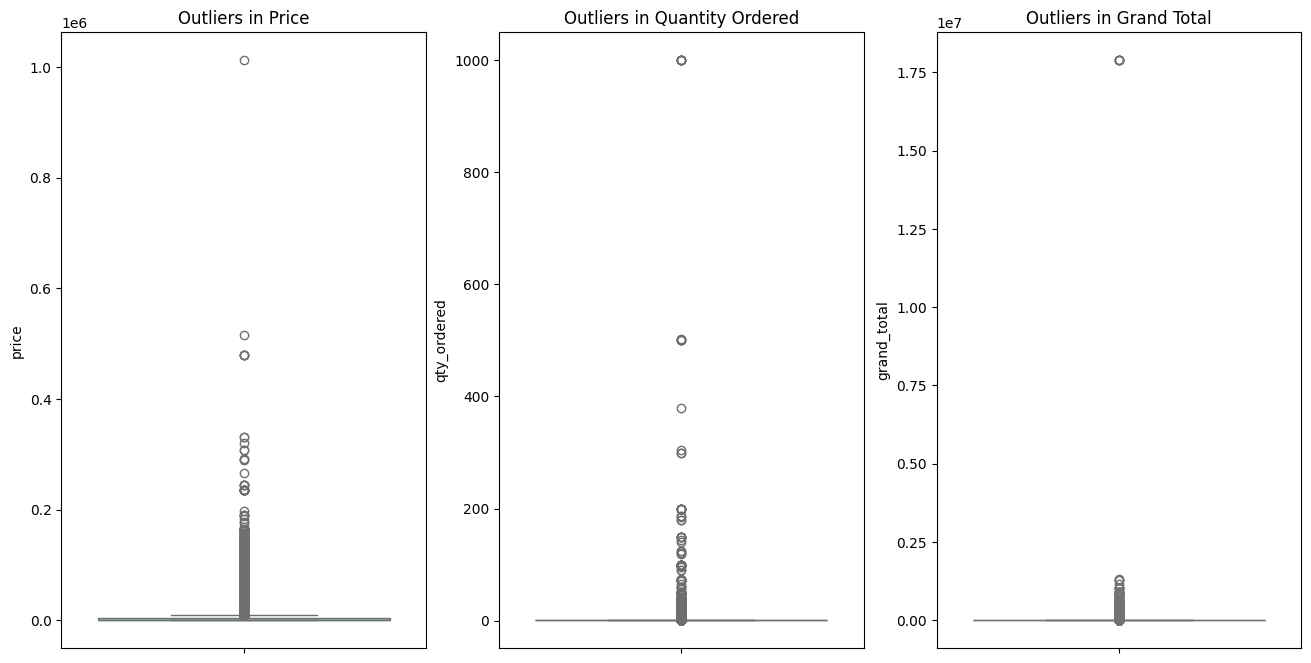

In [203]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['price'], color='skyblue')
plt.title('Outliers in Price')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['qty_ordered'], color='salmon')
plt.title('Outliers in Quantity Ordered')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['grand_total'], color='lightgreen')
plt.title('Outliers in Grand Total')

plt.show()

In [179]:
df_clean = df[(df['price'] < 300000) & (df['grand_total'] < 500000)].copy()

print("Max Grand Total after clean:", df_clean['grand_total'].max())
print("Max Price after clean:", df_clean['price'].max())
print("Max Qty after clean:", df_clean['qty_ordered'].max())
print(f"Cleaned Data Shape: {df_clean.shape}")

Max Grand Total after clean: 499547.0
Max Price after clean: 291667.0
Max Qty after clean: 502.0
Cleaned Data Shape: (578423, 22)


In [180]:
df_clean.describe()

,item_id,created_at,price,qty_ordered,grand_total,discount_amount,Working Date,MV,Year,Month,Customer Since,Customer ID,item_total
count,578423.00,578423,578423.00,578423.00,578423.00,578423.00,578423,578423.00,578423.00,578423.00,578423,578423.00,578423.00
mean,567960.09,2017-08-10 20:22:43.140815872,6343.95,1.28,8259.22,464.39,2017-08-10 20:22:43.140815872,7055.30,2017.05,7.16,2017-04-26 19:20:19.588432640,46104.27,6590.91
min,211133.00,2016-07-01 00:00:00,0.00,1.00,0.00,0.00,2016-07-01 00:00:00,0.00,2016.00,1.00,2016-07-01 00:00:00,2.00,0.00
25%,399137.00,2017-02-06 00:00:00,362.00,1.00,949.00,0.00,2017-02-06 00:00:00,399.00,2017.00,4.00,2016-11-01 00:00:00,13819.00,350.00
50%,571478.00,2017-08-23 00:00:00,900.00,1.00,1975.00,0.00,2017-08-23 00:00:00,999.00,2017.00,7.00,2017-05-01 00:00:00,43373.00,940.00
75%,740501.00,2018-02-08 00:00:00,4000.00,1.00,6973.05,157.09,2018-02-08 00:00:00,4999.00,2018.00,11.00,2017-11-01 00:00:00,73867.50,4499.00
max,905205.00,2018-08-28 00:00:00,291667.00,502.00,499547.00,90300.00,2018-08-28 00:00:00,489998.00,2018.00,12.00,2018-08-01 00:00:00,115326.00,489998.00
std,199348.11,NaN,14782.22,2.38,19880.48,1414.94,NaN,17498.74,0.71,3.49,NaN,34388.45,16891.45


In [181]:
df_clean.to_csv("Cleaned_Dataset.csv", index=False)

#Insights

# Insight 1 : Best-selling categories

In [210]:
best_selling_categ = (df_clean.groupby("category_name_1", observed=True).agg({"item_total": "sum","qty_ordered": "sum","item_id": "count"}).sort_values("item_total", ascending=False))
best_selling_categ

,item_total,qty_ordered,item_id
category_name_1,,,
Mobiles & Tablets,2112770970.20,126575.00,115787
Appliances,557760798.45,58231.00,52439
Entertainment,471909812.13,27326.00,26295
Computing,170002302.17,17235.00,15919
Others,166546800.48,86548.00,30652
Women's Fashion,103596430.69,64215.00,59720
Men's Fashion,83882160.62,101583.00,92295
Beauty & Grooming,36853775.73,53778.00,41487
Superstore,34693630.67,83352.00,44000


/tmp/ipykernel_1021/586594290.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1021/586594290.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




Text(0, 0.5, '')

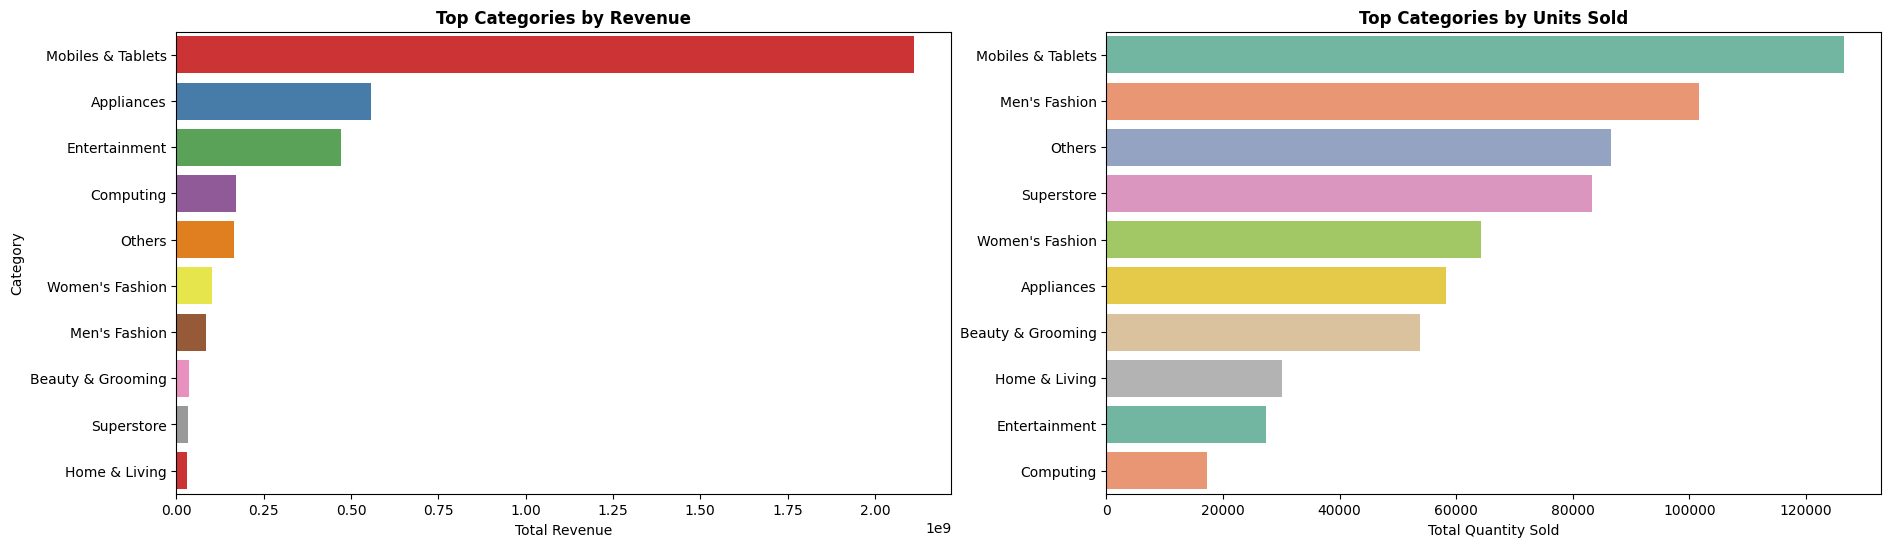

In [183]:
top_10 = best_selling_categ.head(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(22, 6))


df_rev = top_10.sort_values('item_total', ascending=False)
sns.barplot(ax=axes[0], data=df_rev, x='item_total', y='category_name_1', order=df_rev['category_name_1'], palette='Set1')
axes[0].set_title('Top Categories by Revenue', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Revenue')
axes[0].set_ylabel('Category')

df_qty = top_10.sort_values('qty_ordered', ascending=False)
sns.barplot(ax=axes[1], data=df_qty, x='qty_ordered', y='category_name_1', order=df_qty['category_name_1'], palette='Set2')
axes[1].set_title('Top Categories by Units Sold', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Quantity Sold')
axes[1].set_ylabel('')

The best selling category is Mobiles and tablets in Revenue and Quantity

# Insight 2 : Average Order Value by Payment Method

In [184]:
aov_payment = ( df_clean[df_clean['status'].isin(['complete', 'received'])].drop_duplicates(subset=['increment_id']).groupby('payment_method', observed=True).agg({'grand_total': ['mean', 'sum'],'item_id': 'count'}) )
aov_payment.columns = ['aov', 'total_revenue', 'order_count']
aov_payment = aov_payment.sort_values(by='aov', ascending=False).reset_index()
aov_payment.head(10)

,payment_method,aov,total_revenue,order_count
0,financesettlement,111658.00,669948.00,6
1,easypay_voucher,18862.74,310499577.79,16461
2,bankalfalah,17874.84,68103141.32,3810
3,jazzvoucher,12138.25,67003137.90,5520
4,ublcreditcard,10186.64,1232582.88,121
5,Payaxis,9598.80,188203709.98,19607
6,marketingexpense,9345.67,28037.00,3
7,Easypay,9342.34,175467738.54,18782
8,apg,7892.04,1562623.97,198
9,Easypay_MA,7150.38,19091523.98,2670


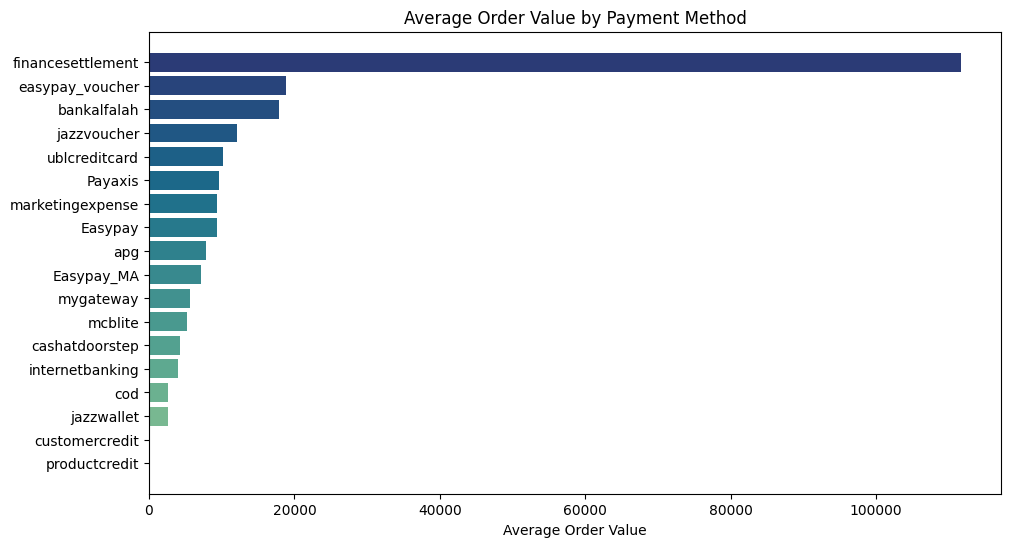

In [185]:
fig, ax = plt.subplots(figsize=(11, 6))

plot_pm = aov_payment.sort_values("aov", ascending=True)
bars = ax.barh(plot_pm['payment_method'], plot_pm["aov"], color=sns.color_palette("crest", len(plot_pm)))
ax.set_xlabel("Average Order Value")
ax.set_title("Average Order Value by Payment Method")

plt.show()

The financesettlement method demonstrates an exceptionally high Average Order Value (exceeding 120,000), indicating its primary use for high-ticket corporate transactions, B2B settlements, or bulk purchases.

Alternative digital channels such as easypay_voucher and bankalfalah capture significantly higher average order values compared to conventional payment methods, making them ideal channels for promoting premium product categories.

Traditional channels like Cash on Delivery (cod) and digital wallets (e.g., jazzwallet) exhibit lower average order values, confirming that consumers predominantly utilize these options for low-ticket, routine, or impulse purchases.


# Insight 3 : monthly sales trend

In [211]:
monthly = (df_clean[df_clean['status'].isin(['complete', 'received'])] .assign(month=df_clean["created_at"].dt.to_period("M").dt.to_timestamp())
            .groupby("month").agg(total_sales=("item_total", "sum"),orders=("increment_id", "nunique")).reset_index())

monthly

,month,total_sales,orders
0,2016-07-01,7702527.83,4421
1,2016-08-01,14948493.15,6402
2,2016-09-01,16761267.76,6492
3,2016-10-01,12077183.57,5856
4,2016-11-01,69768695.93,30027
5,2016-12-01,20321589.38,6519
6,2017-01-01,24624307.47,5858
7,2017-02-01,19679211.59,4867
8,2017-03-01,29829223.07,7422
9,2017-04-01,23622999.22,7053


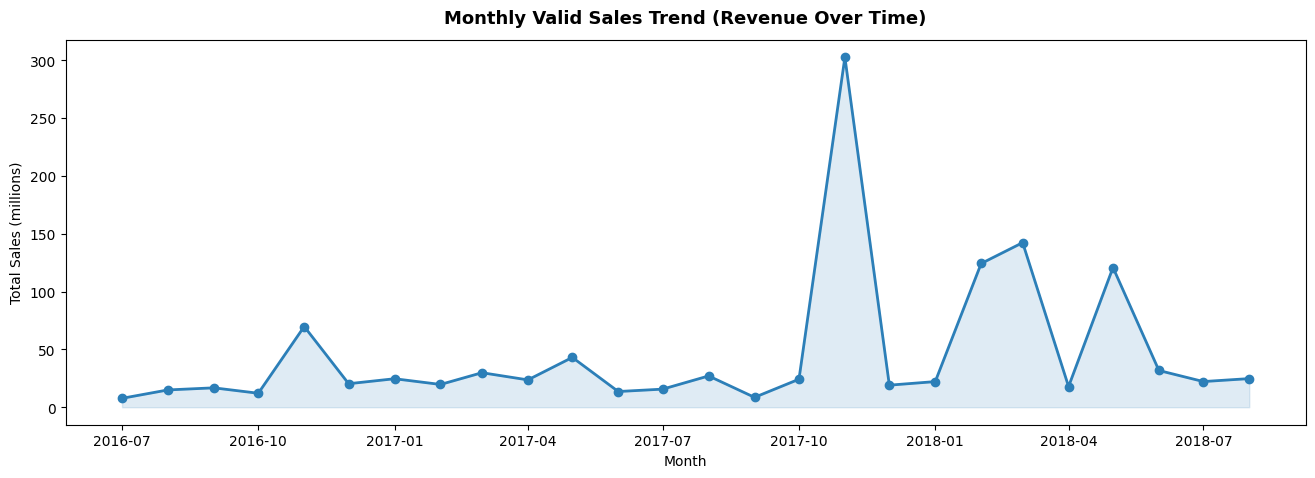

In [187]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(monthly["month"], monthly["total_sales"] / 1e6, marker="o", color="#2c7fb8", linewidth=2)
ax.fill_between(monthly["month"], monthly["total_sales"] / 1e6, alpha=0.15, color="#2c7fb8")

ax.set_title("Monthly Valid Sales Trend (Revenue Over Time)", fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel("Total Sales (millions)", fontsize=10)
ax.set_xlabel("Month", fontsize=10)

plt.show()

The monthly trend highlights clear promotional seasonality, with significant spikes in overall sales revenue during specific months (driven by major campaign events like Black Friday or holiday sales).

Following peak promotion months, sales experience a standard market cooldown, showing lower revenue baseline in adjacent quarters.

# Insight 4 : effect of discounts on sales.

In [188]:

df_clean["is_discounted"] = df_clean["discount_amount"] > 0


discount_effect = df_clean.groupby("is_discounted").agg(orders=("item_id", "count"),avg_order_value=("grand_total", "mean"),avg_qty=("qty_ordered", "mean"))

discount_effect.index = discount_effect.index.map({True: "Discounted", False: "Not discounted"})
discount_effect = discount_effect.round(2)

discount_effect

,orders,avg_order_value,avg_qty
is_discounted,,,
Not discounted,371219,7652.44,1.31
Discounted,207204,9346.30,1.24


In [189]:
fig = px.bar(
    discount_effect.reset_index(),
    x="is_discounted",
    y="avg_order_value",
    title="Average Order Value: Discounted vs Not",
    labels={
        "is_discounted": "Discount Status",
        "avg_order_value": "Avg Order Value",
    },
    color="is_discounted",
    color_discrete_sequence=["red", "green"],
    text_auto=".2f",
)

fig.update_layout(
    showlegend=False, template="plotly_white", title_x=0.5, height=500, width=700
)


fig.show()

Orders with discounts generated a higher Average Order Value (AOV) compared to non-discounted orders.

Offering discounts successfully incentivized customers to add more items to their carts, effectively driving up total spending per order.

# Insight 5: Top-Selling Product / Most Popular Items

In [221]:
top_products = (
    df_clean[df_clean["status"].isin(["complete", "received"])]
    .groupby(["sku", "category_name_1"])
    .agg(
        total_qty=("qty_ordered", "sum"),
        total_revenue=("item_total", "sum"),
        order_count=("item_id", "count"),
    )
    .sort_values(by="total_qty", ascending=False)
    .head(10)
    .reset_index()
)

top_products

/tmp/ipykernel_1021/1316121128.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,sku,category_name_1,total_qty,total_revenue,order_count
0,MATSAM59DB75ADB2F80,Mobiles & Tablets,2869.00,33020251.37,2865
1,VIT5ABCCF7FDF973,Superstore,2421.00,1568557.98,552
2,Al Muhafiz Sohan Halwa Almond,Soghaat,1827.00,648954.10,1552
3,kcc_krone deal,Beauty & Grooming,1808.00,623927.51,1597
4,BAGLUX5A099F4DDC6A7,Beauty & Grooming,1495.00,218100.33,119
5,RS_Plain Rusk Pack of 3,Soghaat,1292.00,205883.38,726
6,emart_00-7,Home & Living,1255.00,689873.43,1083
7,RB_Veet-bf,Superstore,1211.00,437644.14,504
8,RS_Plain Rusk,Soghaat,1183.00,65065.00,613
9,BAGLUX5A099F4E3D5CF,Beauty & Grooming,999.00,171017.03,178


In [222]:
fig = px.bar(
    top_products.reset_index().sort_values("total_revenue"),
    x="total_revenue", y="sku", orientation="h", color="category_name_1",
    title="Top 10 SKUs by Revenue",
    labels={"total_revenue": "Total Sales", "sku": "SKU"},
)
fig.update_yaxes(categoryorder="total ascending")
fig.update_layout(height=500)
fig.show()

In [223]:
fig = px.bar(
    top_products.reset_index().sort_values("total_qty"),
    x="total_qty", y="sku", orientation="h", color="category_name_1",
    title="Top 10 SKUs by Best selling",
    labels={"total_qty": "Best selling", "sku": "SKU"},
)
fig.update_yaxes(categoryorder="total ascending")
fig.update_layout(height=500)
fig.show()

Sales are heavily concentrated in the top product (MATSAM59DB75ADB2F80), which significantly outperforms all other SKUs, generating the vast majority of total revenue and best selling among top sellers.

Note on Outliers:
SKU MATSAM59DB75ADB2F80 represents an extreme revenue outlier (likely due to high-value hardware/bulk purchases)

# Insight 6: Revenue Breakdown by Order Status

In [216]:
status = (
    df_clean.groupby("status", observed=True)
      .agg(orders=("item_id", "count"), total_qty=("qty_ordered", "sum"), total_sales=("grand_total", "sum"))
      .sort_values("total_sales", ascending=False)
)
status


,orders,total_qty,total_sales
status,,,
canceled,198848,270127.00,2758959398.20
complete,231227,274348.00,1119002749.58
received,77188,110160.00,434834784.43
order_refunded,58565,73031.00,406193247.49
refund,7906,9447.00,30086111.04
cod,2853,3358.00,12372872.48
paid,1157,1720.00,8808178.70
closed,492,536.00,3597710.54
pending,48,70.00,1253714.60


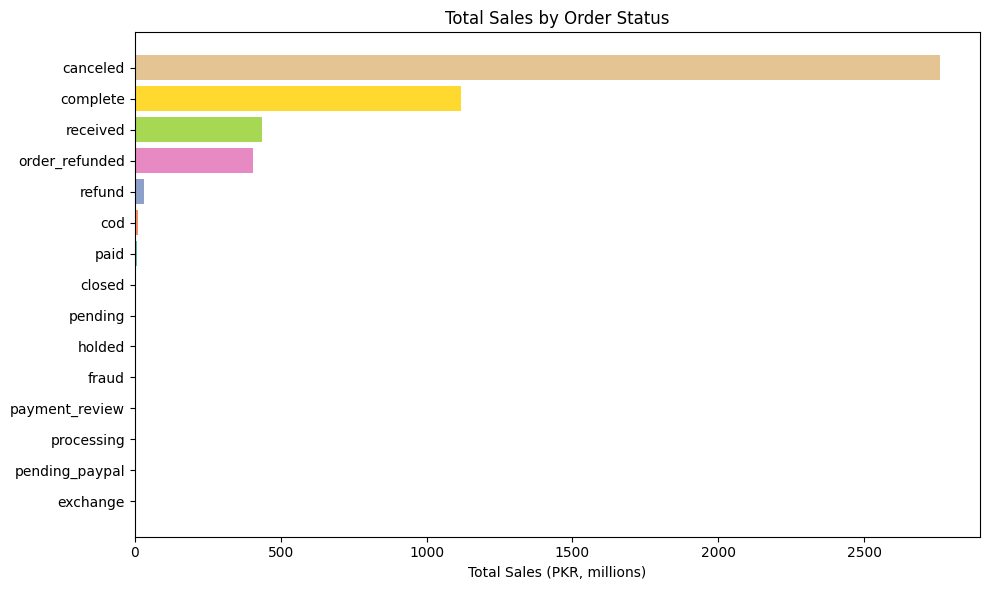

In [193]:
fig, ax = plt.subplots(figsize=(10, 6))
top_status = status.sort_values("total_sales")
ax.barh(top_status.index, top_status["total_sales"] / 1e6, color=sns.color_palette("Set2"))
ax.set_xlabel("Total Sales (PKR, millions)")
ax.set_title("Total Sales by Order Status")
plt.tight_layout()
plt.show()


Dominant Canceled Volume: Sales under the canceled status significantly surpass complete orders, indicating a massive loss of potential top-line revenue before fulfillment.

Realized vs. Lost Revenue: While actual realized sales (complete + received) form a strong revenue baseline, the combined volume of canceled, order_refunded, and refund highlights major operational and conversion bottlenecks.

# Insight 7: Revenue by Price

In [224]:

df_complete = df_clean[df_clean["status"].isin(["complete", "received"])].copy()
df_complete["price_tier"] = pd.qcut(
    df_complete["price"], q=3, labels=["Low Price", "Mid Price", "High Price"]
)

tier_summary = (
    df_complete.groupby("price_tier")
    .agg(
        total_revenue=("item_total", "sum"),
        total_qty=("qty_ordered", "sum"),
        avg_price=("price", "mean"),
    )
    .reset_index()
)

tier_summary

/tmp/ipykernel_1021/461623348.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,price_tier,total_revenue,total_qty,avg_price
0,Low Price,25958606.91,146632.00,216.06
1,Mid Price,83397051.96,124125.00,732.88
2,High Price,1089609429.81,113751.00,10878.22


In [225]:
fig = px.bar(
    tier_summary,
    x="price_tier",
    y="total_revenue",
    title="Total Revenue by Price Tier (Log Scale)",
    labels={
        "price_tier": "Price Tier",
        "total_revenue": "Total Revenue",
    },
    color="price_tier",
    color_discrete_sequence=["#2a9d8f", "#e76f51", "#264653"],
    text_auto=".2s",
    log_y=True,
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=500,
    showlegend=False,
    yaxis_title="Total Revenue (Log Scale)",
    xaxis_title="Price Tier",
)

fig.show()

The High Price tier generates the vast majority of total sales (~1.1B PKR), dwarfing the combined contribution of Mid Price (62M PKR) and Low Price (26M PKR) tiers due to extreme high-ticket outliers.

 While Low and Mid Price tiers account for lower top-line revenue, they serve as the operational backbone for transaction frequency and customer acquisition.

# Insight 8: Sales Code Performance

In [226]:
sales_code_summary = (
    df_clean[df_clean["status"].isin(["complete", "received"])]
    .groupby("sales_commission_code")
    .agg(
        total_orders=("item_id", "count"),
        total_revenue=("item_total", "sum"),
    )
    .reset_index()
    .sort_values(by="total_revenue", ascending=False)
    .head(10)
)

sales_code_summary

,sales_commission_code,total_orders,total_revenue
3443,No Commission,239457,773591481.98
3059,C_LHC_30667,365,16669663.92
602,40968,1827,14505531.32
3620,R-GUJ-105814,980,13693040.64
2973,CMUX33202,827,13436337.44
3622,R-GUJ-106946,625,11325011.41
4788,cisb30211,1087,10558190.04
4548,c-lhc-30667,790,10093214.62
3887,R-MUX-104361,755,9133495.95
4768,cfsd30642,721,8398478.21


In [227]:
fig = px.bar(
    sales_code_summary.sort_values(by="total_revenue", ascending=True),
    x="total_revenue",
    y="sales_commission_code",
    orientation="h",
    title="Top 10 Sales Codes by Revenue",
    labels={
        "total_revenue": "Total Revenue",
        "sales_commission_code": "Sales Code",
    },
    color="total_revenue",
    color_continuous_scale="Viridis",
    text_auto=".2s",
)



fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=500,
    coloraxis_showscale=False,
)

fig.show()

Organic vs. Affiliate Dominance: The vast majority of sales revenue (~770M PKR) is driven by "No Commission" transactions, indicating that standard organic traffic and direct sales heavily outweigh promotional/affiliate-driven codes.

Top Commissioned Performer: Among active promotional codes, C_LHC_30667 leads the channel with ~17M PKR, followed by 40968 (15M PKR) and R-GUJ-105814 (14M PKR).

# Insight 9: Year-over-Year Growth by Fiscal Year (FY Trend)

In [228]:
fy_summary = (
    df_clean[df_clean["status"].isin(["complete", "received"])]
    .groupby("FY")
    .agg(
        total_orders=("item_id", "count"),
        total_revenue=("item_total", "sum"),
        avg_order_value=("item_total", "mean"),
    )
    .reset_index()
    .sort_values(by="FY")
)

fy_summary["yoy_revenue_growth_%"] = (
    fy_summary["total_revenue"].pct_change() * 100
)

fy_summary

,FY,total_orders,total_revenue,avg_order_value,yoy_revenue_growth_%
0,FY17,141911,295964400.09,2085.56,NaN
1,FY18,157073,856068219.29,5450.13,189.25
2,FY19,9431,46932469.30,4976.40,-94.52


In [230]:
fig = px.bar(
    fy_summary,
    x="FY",
    y="total_revenue",
    title="Year-over-Year Revenue Growth by Fiscal Year",
    labels={
        "FY": "Fiscal Year",
        "total_revenue": "Total Revenue",
    },
    color="FY",
    color_discrete_sequence=px.colors.qualitative.Pastel,
    text_auto=".2s",
)


fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=500,
    showlegend=False,
    xaxis_title="Fiscal Year",
    yaxis_title="Total Revenue ",
)

fig.show()

Total realized revenue experienced massive Year-over-Year (YoY) expansion, jumping from 300M PKR in FY17 to 860M PKR in FY18 (more than doubling revenue volume).

FY19 Anomalous Drop: The steep decline to 47k PKR in FY19 reflects incomplete/partial period data rather than an operational collapse, requiring date-range truncation before drawing annual trend conclusions.

# Insight 10: Order Completion & Operational Health

In [231]:
total_orders_count = len(df_clean)
completed_orders_count = len(df_clean[df_clean["status"].isin(["complete", "received"])])
canceled_orders_count = len(df_clean[df_clean["status"] == "canceled"])
refunded_orders_count = len(
    df_clean[df_clean["status"].isin(["order_refunded", "refund"])]
)

completion_rate = (completed_orders_count / total_orders_count) * 100
cancellation_rate = (canceled_orders_count / total_orders_count) * 100
refund_rate = (refunded_orders_count / total_orders_count) * 100

health_metrics = pd.DataFrame(
    {
        "Metric": [
            "Completion Rate",
            "Cancellation Rate",
            "Refund/Return Rate",
        ],
        "Percentage (%)": [completion_rate, cancellation_rate, refund_rate],
    }
)

health_metrics.round(2)

,Metric,Percentage (%)
0,Completion Rate,53.32
1,Cancellation Rate,34.38
2,Refund/Return Rate,11.49


In [232]:
fig = px.pie(
    health_metrics,
    names="Metric",
    values="Percentage (%)",
    title="Operational Health & Order Fulfillment Breakdown",
    hole=0.5,
    color="Metric",
    color_discrete_map={
        "Completion Rate": "#2a9d8f",
        "Cancellation Rate": "#e76f51",
        "Refund/Return Rate": "#f4a261",
    },
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=500,
)

fig.show()

Low Order Completion Baseline: more than half of total orders reach successful completion (53.8%), revealing that more than 46% of overall demand fails to convert into realized revenue.

High Cancellation & Return Leakage: Order cancellations represent a massive operational drop-off (34.7%), combined with a 13.4% refund/return rate, pointing directly to fulfillment friction, inventory stockouts, or payment gateway failures.